In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
train = pd.read_csv('train.csv')

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train['Survived']

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

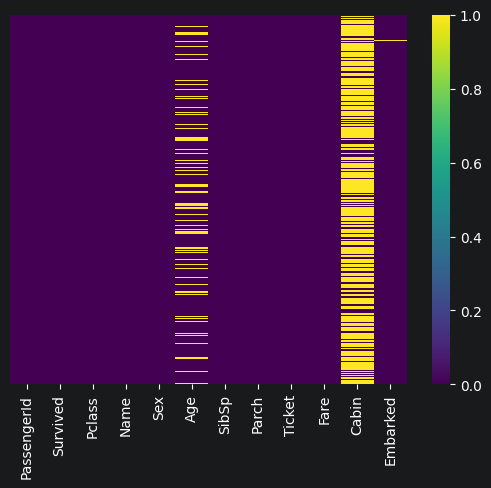

In [5]:
sns.heatmap(train.isnull(),yticklabels=False,cmap='viridis')
plt.show()

In [6]:
train['Cabin'].isna().sum(),len(train)

(np.int64(687), 891)

In [7]:
687/891*100


77.10437710437711

<Axes: xlabel='Survived', ylabel='count'>

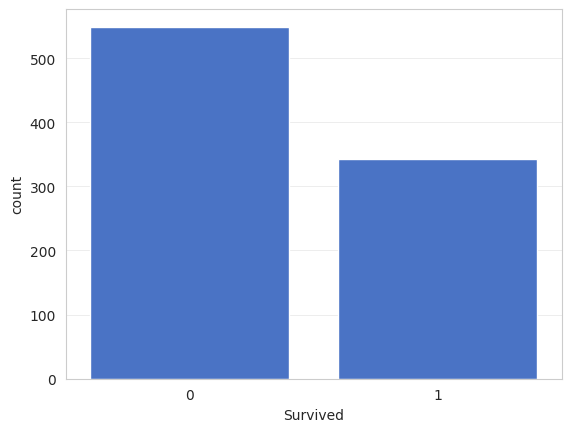

In [8]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',data = train)

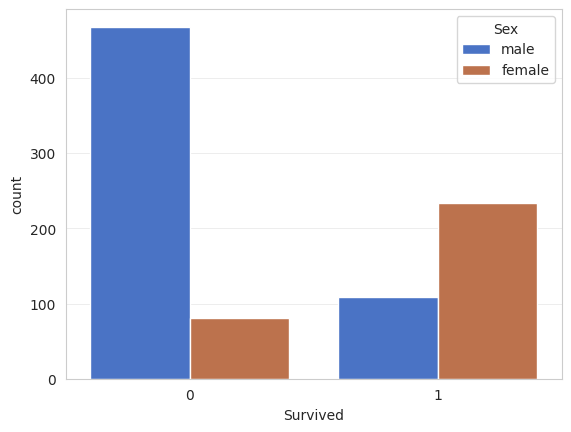

In [9]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Sex', data = train)
plt.show()

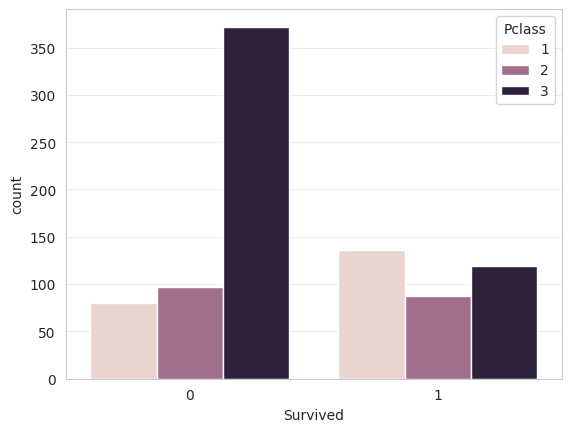

In [10]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Pclass', data = train)
plt.show()

In [11]:
train['Pclass'].unique()
train['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

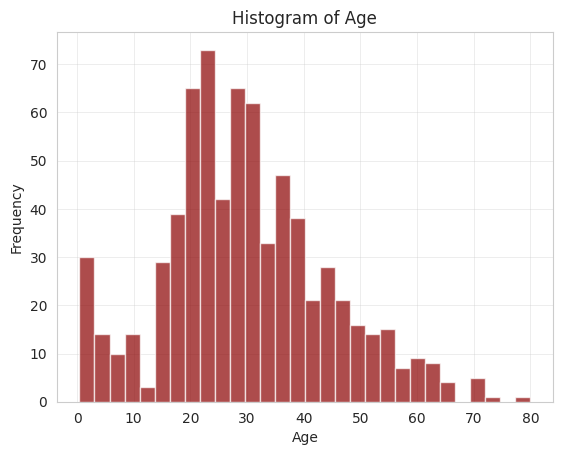

In [12]:
age_hist = train['Age'].hist(bins=30, color='darkred', alpha = 0.7)
age_hist.set_title("Histogram of Age")
age_hist.set_xlabel("Age")
age_hist.set_ylabel("Frequency")
plt.show()

In [13]:
    train['Age'].mean()

np.float64(29.69911764705882)

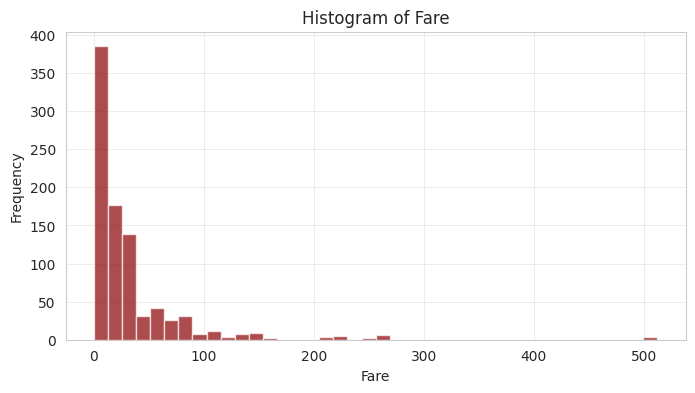

In [14]:
age_hist = train['Fare'].hist(bins=40, color='darkred', alpha = 0.7,figsize=(8,4))
age_hist.set_title("Histogram of Fare")
age_hist.set_xlabel("Fare")
age_hist.set_ylabel("Frequency")
plt.show()

# Find the 258th row and unique Cabin and Embarked

In [21]:
train.iloc[1]

PassengerId                                                    2
Survived                                                       1
Pclass                                                         1
Name           Cumings, Mrs. John Bradley (Florence Briggs Th...
Sex                                                       female
Age                                                         38.0
SibSp                                                          1
Parch                                                          0
Ticket                                                  PC 17599
Fare                                                     71.2833
Cabin                                                        C85
Embarked                                                       C
Name: 1, dtype: object

In [24]:
train['Embarked'].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

# Short Form
 S -> Southampton, England
C -> Cherbourg, France
Q -> Queenstown, Ireland

In [25]:
train['Cabin'].unique()

<StringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

<Axes: xlabel='Pclass', ylabel='Age'>

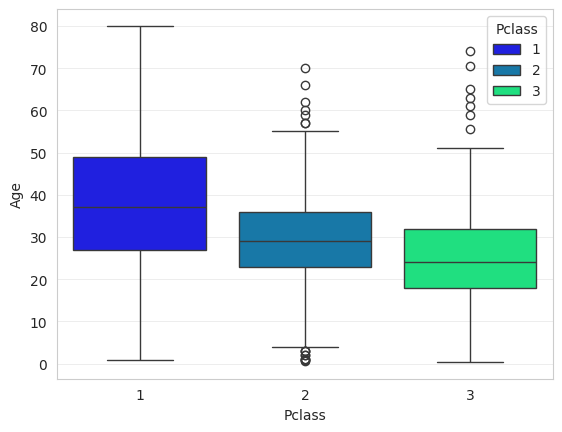

In [34]:
sns.boxplot(x='Pclass', y='Age',data = train, hue ='Pclass',palette ='winter')

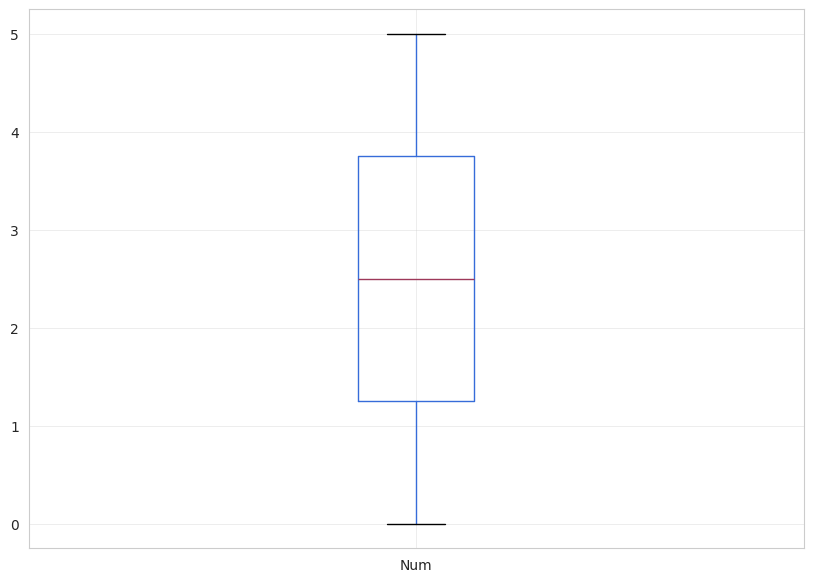

In [33]:
data = [0,1,2,3,4,5]
df = pd.DataFrame(data,columns =['Num'])
plt.figure(figsize = (10,7))
df.boxplot()
plt.show()

In [32]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [46]:
train['Age'].isnull().sum()

np.int64(177)

In [48]:
train.iloc[1]

PassengerId                                                    2
Survived                                                       1
Pclass                                                         1
Name           Cumings, Mrs. John Bradley (Florence Briggs Th...
Sex                                                       female
Age                                                         38.0
SibSp                                                          1
Parch                                                          0
Ticket                                                  PC 17599
Fare                                                     71.2833
Cabin                                                        C85
Embarked                                                       C
Name: 1, dtype: object

In [49]:
train['Age'] = train['Age'].fillna(
train.groupby('Pclass')['Age'].transform('mean')
)

In [51]:
train['Age'].isnull().sum()

np.int64(0)

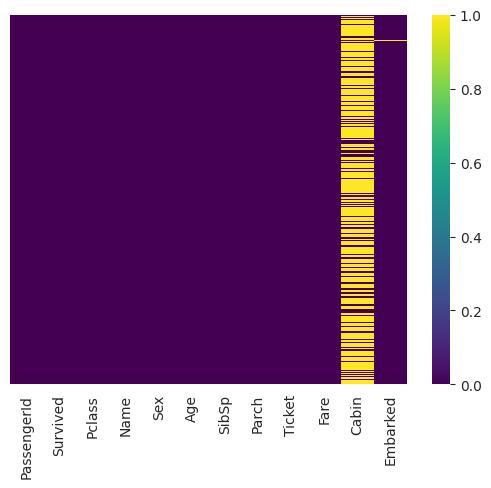

In [52]:
sns.heatmap(train.isnull(),yticklabels=False,cmap='viridis')
plt.show()

In [55]:
train['Cabin'].isnull().sum()/len(train)

np.float64(0.7710437710437711)

In [56]:
train.drop('Cabin',axis = 1,inplace=True)

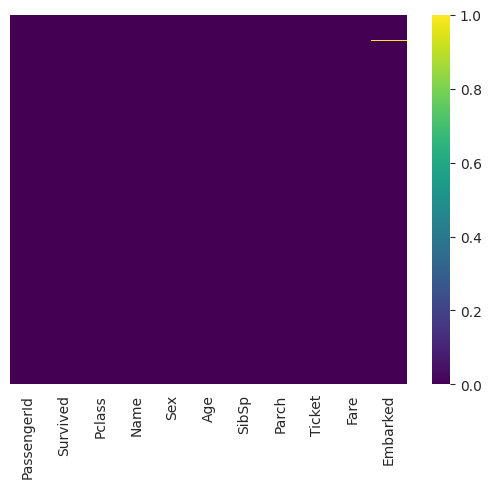

In [57]:
sns.heatmap(train.isnull(),yticklabels=False,cmap='viridis')
plt.show()

In [58]:
train.dropna(inplace=True)

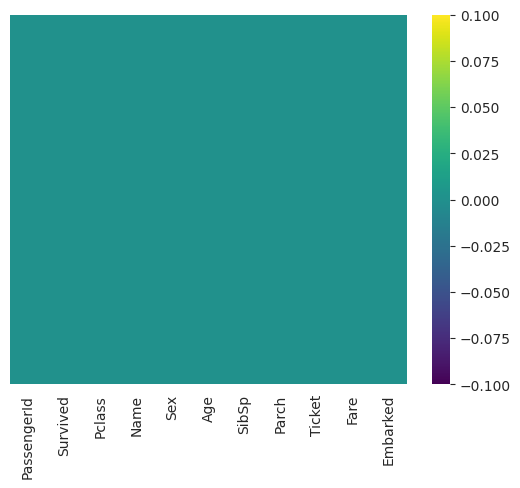

In [59]:
sns.heatmap(train.isnull(),yticklabels=False,cmap='viridis')
plt.show()

In [61]:
train['Embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 889, dtype: str

In [62]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.00000,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.00000,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,25.14062,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.00000,0,0,111369,30.0000,C


In [65]:
train['Embarked'].unique()

<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

In [66]:
sex = pd.get_dummies(train['Sex'])
embark = pd.get_dummies(train['Embarked'])

In [75]:
sex

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True
...,...,...
886,False,True
887,True,False
888,True,False
889,False,True


In [74]:
embark

,C,Q,S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True
...,...,...,...
886,False,False,True
887,False,False,True
888,False,False,True
889,True,False,False


In [71]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [78]:
train = pd.concat([train,embark,sex],axis=1)

In [83]:
train.drop(['Sex','Embarked','Name','Ticket'],axis=1,inplace=True)

In [84]:
train

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,C,Q,S,female,male
0,1,0,3,22.00000,1,0,7.2500,False,False,True,False,True
1,2,1,1,38.00000,1,0,71.2833,True,False,False,True,False
2,3,1,3,26.00000,0,0,7.9250,False,False,True,True,False
3,4,1,1,35.00000,1,0,53.1000,False,False,True,True,False
4,5,0,3,35.00000,0,0,8.0500,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.00000,0,0,13.0000,False,False,True,False,True
887,888,1,1,19.00000,0,0,30.0000,False,False,True,True,False
888,889,0,3,25.14062,1,2,23.4500,False,False,True,True,False
889,890,1,1,26.00000,0,0,30.0000,True,False,False,False,True


In [ ]:
|